In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    mean_squared_error, roc_curve, auc
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13})
PALETTE = sns.color_palette('Set2')
print('✔ Thư viện sẵn sàng')

✔ Thư viện sẵn sàng


In [2]:
RANDOM_STATE  = 42
TEST_SIZE     = 0.2
N_ESTIMATORS  = 200
DATA_PATH     = 'data_clean.csv'
LABEL_COL     = 'label'          # cột nhãn trong data_clean.csv
CLASSES_ORDER = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']
OUTPUT_DIR    = '.'

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nPhân bố nhãn:')
display(df[LABEL_COL].value_counts().to_frame('count'))

Shape: (51579, 49)

Phân bố nhãn:


,count
label,
anger,9178
sad,8969
fear,8732
happy,8578
disgust,8264
neutral,7858


In [4]:
feature_cols = [c for c in df.columns if c != LABEL_COL]
X_raw = df[feature_cols].values
y_raw = df[LABEL_COL].values

le = LabelEncoder()
le.fit(CLASSES_ORDER)
y         = le.transform(y_raw)
classes   = le.classes_
n_classes = len(classes)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 41,263 | Test: 10,316


In [5]:
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fracs  = np.linspace(0.1, 1.0, 8)
n_axis = [int(f * X_train.shape[0]) for f in fracs]
tr_acc, vl_acc = [], []

for n in n_axis:
    Xs, ys = X_train[:n], y_train[:n]
    t_s, v_s = [], []
    for tr_i, vl_i in cv.split(Xs, ys):
        m = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE)
        m.fit(Xs[tr_i], ys[tr_i])
        t_s.append(m.score(Xs[tr_i], ys[tr_i]))
        v_s.append(m.score(Xs[vl_i], ys[vl_i]))
    tr_acc.append(np.mean(t_s))
    vl_acc.append(np.mean(v_s))
    print(f'  n={n:>6,}  train={np.mean(t_s):.3f}  val={np.mean(v_s):.3f}')

  n= 4,126  train=1.000  val=0.707
  n= 9,431  train=1.000  val=0.746
  n=14,736  train=1.000  val=0.767
  n=20,042  train=1.000  val=0.772
  n=25,347  train=1.000  val=0.780
  n=30,652  train=1.000  val=0.791
  n=35,957  train=1.000  val=0.797
  n=41,263  train=1.000  val=0.801


In [6]:
rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, max_features='sqrt',
    oob_score=True, n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
print(f'✔ OOB Score: {rf.oob_score_:.4f}')

✔ OOB Score: 0.8163


In [7]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)

f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_micro    = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
mse         = mean_squared_error(y_test, y_pred)
rmse        = np.sqrt(mse)

print(f'F1 Macro    : {f1_macro:.4f}')
print(f'F1 Micro    : {f1_micro:.4f}')
print(f'F1 Weighted : {f1_weighted:.4f}')
print(f'MSE         : {mse:.4f}')
print(f'RMSE        : {rmse:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=classes))

F1 Macro    : 0.8259
F1 Micro    : 0.8268
F1 Weighted : 0.8276
MSE         : 0.8116
RMSE        : 0.9009

              precision    recall  f1-score   support

       anger       0.94      0.90      0.92      1836
     disgust       0.79      0.79      0.79      1653
        fear       0.84      0.78      0.81      1746
       happy       0.75      0.84      0.79      1716
     neutral       0.78      0.83      0.80      1571
         sad       0.88      0.82      0.85      1794

    accuracy                           0.83     10316
   macro avg       0.83      0.83      0.83     10316
weighted avg       0.83      0.83      0.83     10316



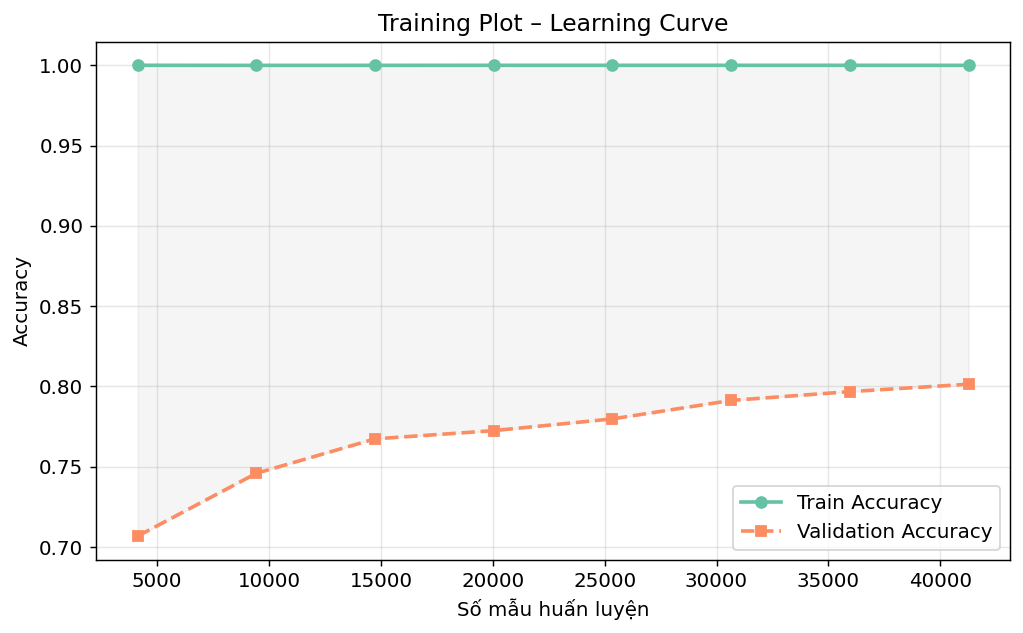

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_axis, tr_acc, 'o-',  color=PALETTE[0], lw=2, label='Train Accuracy')
ax.plot(n_axis, vl_acc, 's--', color=PALETTE[1], lw=2, label='Validation Accuracy')
ax.fill_between(n_axis, tr_acc, vl_acc, alpha=0.08, color='gray')
ax.set_xlabel('Số mẫu huấn luyện'); ax.set_ylabel('Accuracy')
ax.set_title('Training Plot – Learning Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_plot.png', bbox_inches='tight'); plt.show()

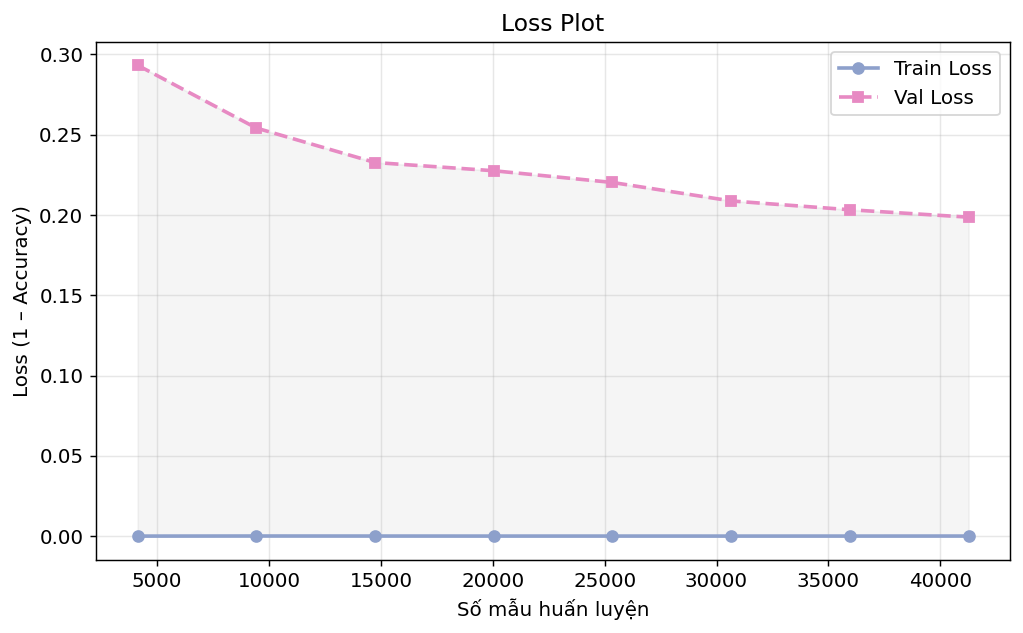

In [9]:
tr_loss = [1 - s for s in tr_acc]
vl_loss = [1 - s for s in vl_acc]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n_axis, tr_loss, 'o-',  color=PALETTE[2], lw=2, label='Train Loss')
ax.plot(n_axis, vl_loss, 's--', color=PALETTE[3], lw=2, label='Val Loss')
ax.fill_between(n_axis, tr_loss, vl_loss, alpha=0.08, color='gray')
ax.set_xlabel('Số mẫu huấn luyện'); ax.set_ylabel('Loss (1 – Accuracy)')
ax.set_title('Loss Plot')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('loss_plot.png', bbox_inches='tight'); plt.show()

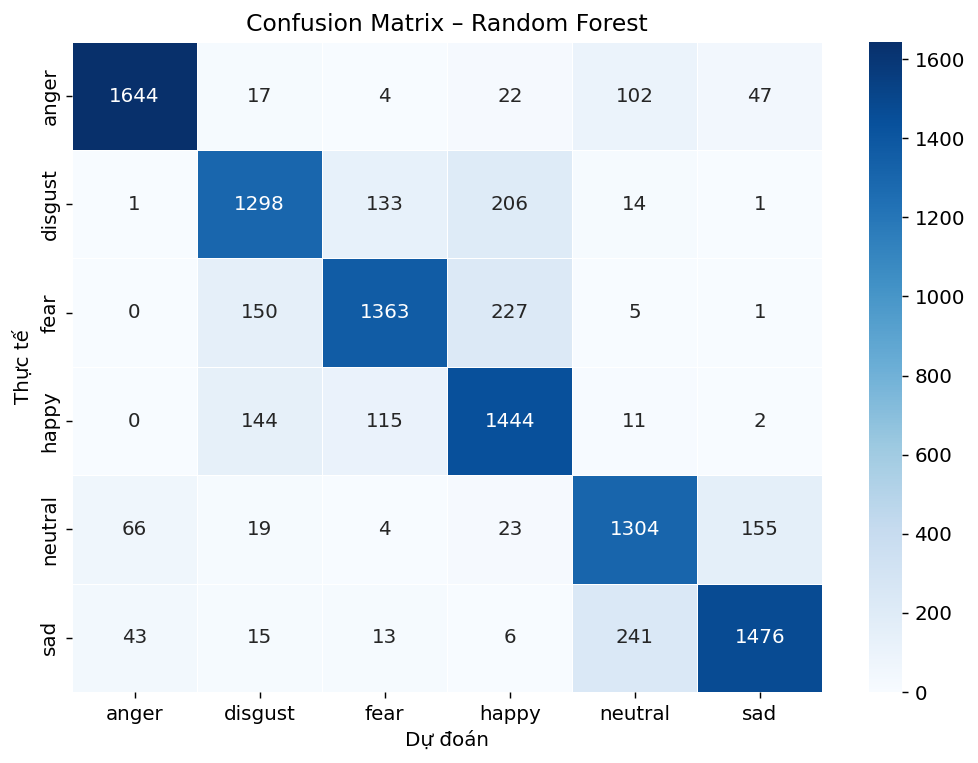

In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            ax=ax, linewidths=0.5, linecolor='white', annot_kws={'size': 11})
ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
ax.set_title('Confusion Matrix – Random Forest')
plt.tight_layout(); plt.savefig('confusion_matrix.png', bbox_inches='tight'); plt.show()

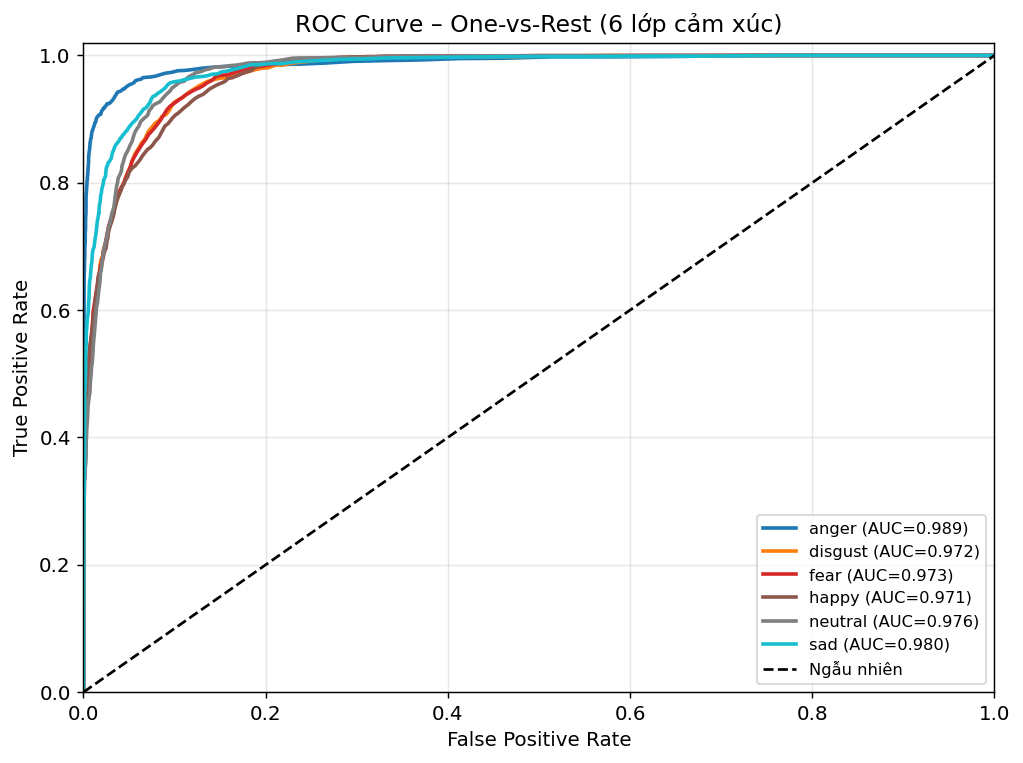

In [11]:
y_bin      = label_binarize(y_test, classes=np.arange(n_classes))
roc_colors = plt.cm.tab10(np.linspace(0, 0.9, n_classes))
fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, col) in enumerate(zip(classes, roc_colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Ngẫu nhiên')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve – One-vs-Rest (6 lớp cảm xúc)')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_plot.png', bbox_inches='tight'); plt.show()

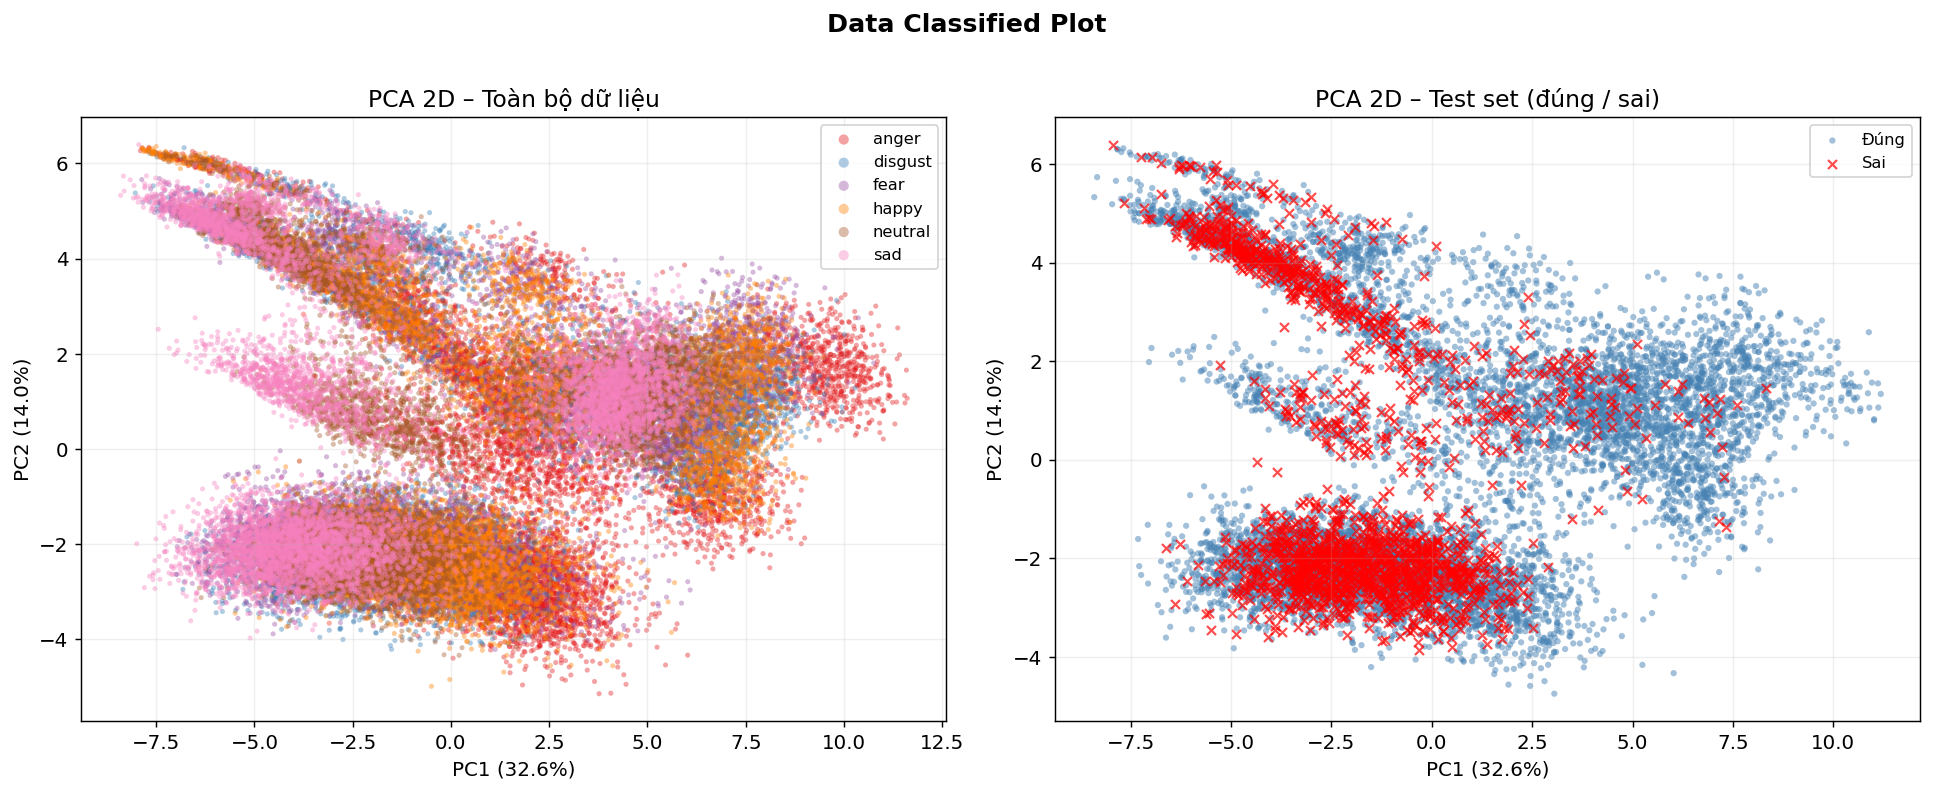

In [12]:
pca      = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d     = pca.fit_transform(X_scaled)
sc_colors = plt.cm.Set1(np.linspace(0, 0.85, n_classes))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for i, (cls, col) in enumerate(zip(classes, sc_colors)):
    mask = y == i
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=[col], label=cls, alpha=0.4, s=8, edgecolors='none')
ax.set_title('PCA 2D – Toàn bộ dữ liệu')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2); ax.grid(alpha=0.2)

ax = axes[1]
X_test_2d = pca.transform(X_test)
correct   = y_pred == y_test
ax.scatter(X_test_2d[correct,0],  X_test_2d[correct,1],  c='steelblue', alpha=0.5, s=12, label='Đúng', edgecolors='none')
ax.scatter(X_test_2d[~correct,0], X_test_2d[~correct,1], c='red', alpha=0.7, s=25, label='Sai', marker='x', linewidths=1.2)
ax.set_title('PCA 2D – Test set (đúng / sai)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.suptitle('Data Classified Plot', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('data_classified_plot.png', bbox_inches='tight'); plt.show()

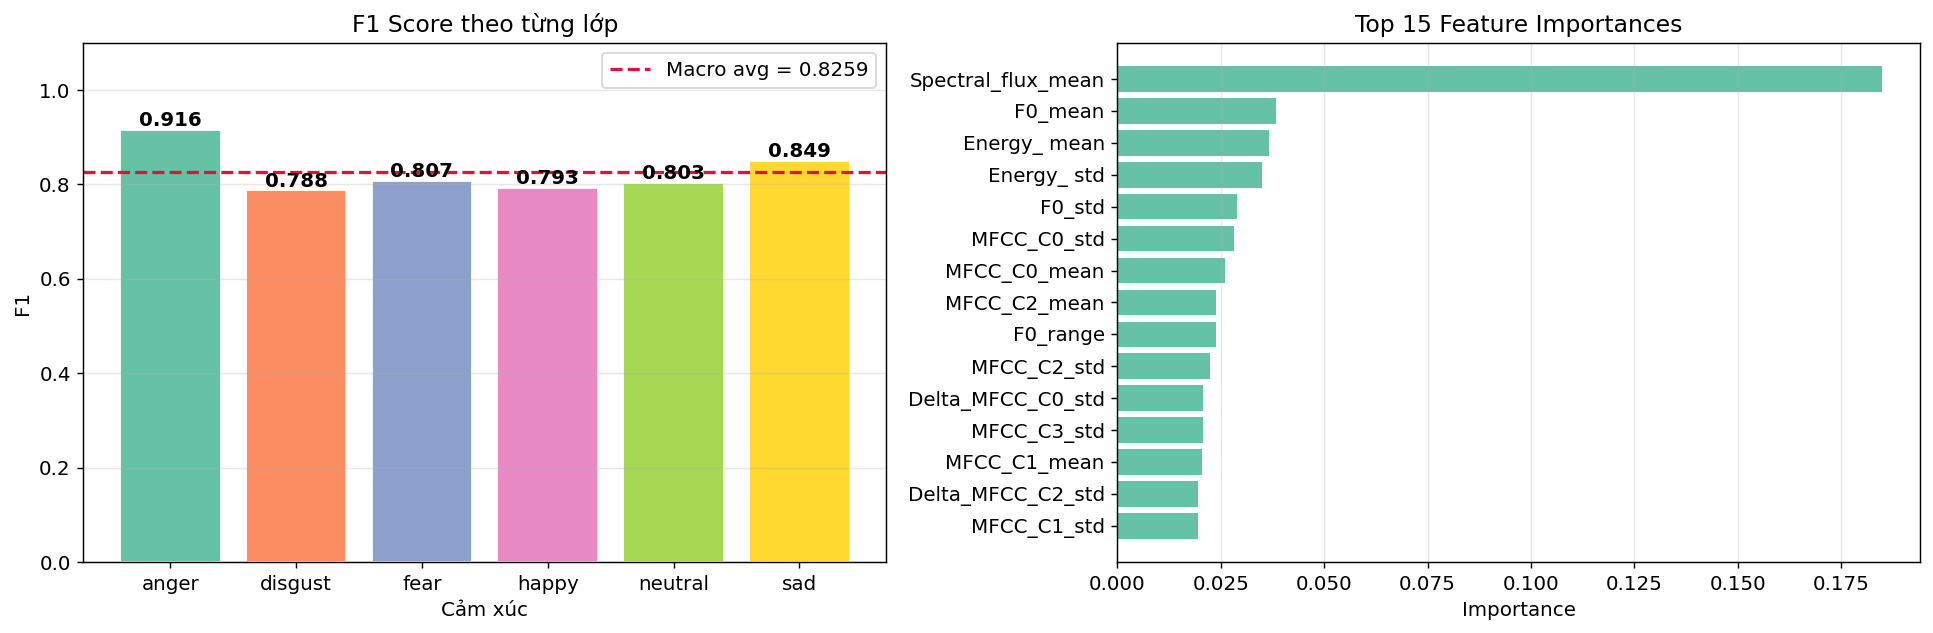

In [13]:
f1_per_class = f1_score(y_test, y_pred, average=None)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
bars = ax.bar(classes, f1_per_class, color=[PALETTE[i%len(PALETTE)] for i in range(n_classes)], edgecolor='white')
ax.axhline(f1_macro, color='crimson', linestyle='--', lw=1.8, label=f'Macro avg = {f1_macro:.4f}')
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0,1.1); ax.set_title('F1 Score theo từng lớp')
ax.set_xlabel('Cảm xúc'); ax.set_ylabel('F1'); ax.legend(); ax.grid(axis='y',alpha=0.3)

ax = axes[1]
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1][:15]
ax.barh([feature_cols[i] for i in idx[::-1]], importances[idx[::-1]], color=PALETTE[0])
ax.set_title('Top 15 Feature Importances'); ax.set_xlabel('Importance'); ax.grid(axis='x',alpha=0.3)

plt.tight_layout(); plt.savefig('f1_feature_importance.png', bbox_inches='tight'); plt.show()

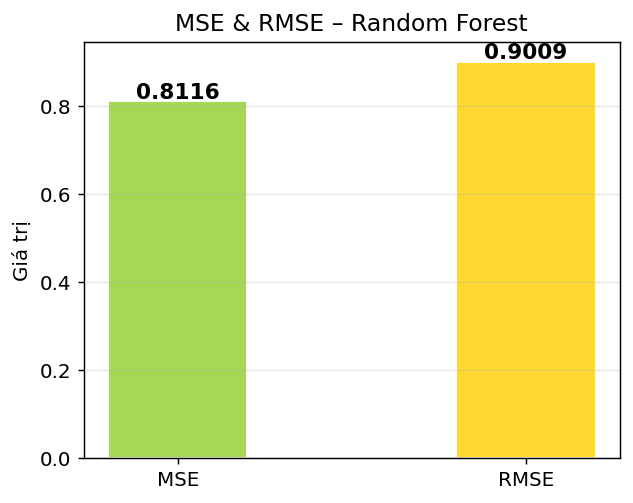

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['MSE','RMSE'], [mse, rmse], color=[PALETTE[4],PALETTE[5]], edgecolor='white', width=0.4)
for bar, val in zip(bars, [mse, rmse]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Giá trị'); ax.set_title('MSE & RMSE – Random Forest'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('mse_rmse_chart.png', bbox_inches='tight'); plt.show()

In [15]:
print('='*55)
print('TỔNG KẾT KẾT QUẢ')
print('='*55)
result = {
    'F1 Macro':    f1_macro,
    'F1 Micro':    f1_micro,
    'F1 Weighted': f1_weighted,
    'MSE':         mse,
    'RMSE':        rmse,
    'OOB Score':   rf.oob_score_,
}
for k,v in result.items():
    print(f'  {k:<15}: {v:.4f}')

display(pd.DataFrame(list(result.items()), columns=['Metric','Value']))

TỔNG KẾT KẾT QUẢ
  F1 Macro       : 0.8259
  F1 Micro       : 0.8268
  F1 Weighted    : 0.8276
  MSE            : 0.8116
  RMSE           : 0.9009
  OOB Score      : 0.8163


,Metric,Value
0,F1 Macro,0.825871
1,F1 Micro,0.826774
2,F1 Weighted,0.827596
3,MSE,0.811555
4,RMSE,0.900863
5,OOB Score,0.816349
